<a href="https://colab.research.google.com/github/nerimenaf/SpyXFamily-DeepLearning-Classification/blob/main/Operation_Strix_Deep_Learning_for_Spy_x_Family_Character_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bing-image-downloader

In [ ]:
from bing_image_downloader import downloader

classes = ["Loid Forger Spy x Family anime",
           "Anya Forger Spy x Family anime",
           "Yor Forger Spy x Family anime"]

for character in classes:
    downloader.download(
        character,
        limit=120,
        output_dir='raw_dataset',
        adult_filter_off=True,
        force_replace=False,
        timeout=120
    )

[%] Downloading Images to /content/raw_dataset/Loid Forger Spy x Family anime


[!!] Indexing page: 1

[%] Indexed 1 Images on Page 1.


[%] Downloading Image #1 from https://iemlabs.com/blogs/wp-content/uploads/sites/4/2023/06/Best-free-ai-art-generator.webp
[%] File Downloaded!



[!!] Indexing page: 2

[%] Indexed 10 Images on Page 2.


[%] Downloading Image #2 from https://skibidi.io/wp-content/uploads/2023/08/Skibidi-Toilet-Meme-Song-1.jpg
[%] File Downloaded!

[%] Downloading Image #3 from https://i.kym-cdn.com/editorials/icons/original/000/005/910/stcover.jpg
[%] File Downloaded!

[%] Downloading Image #4 from https://img-s-msn-com.akamaized.net/tenant/amp/entityid/AA1KJtlR.img?w=1022&h=575&m=4&q=91
[%] File Downloaded!

[%] Downloading Image #5 from https://a10.gaanacdn.com/gn_img/albums/d41WjznWPL/1Wj1Re4o3P/size_m.jpg
[%] File Downloaded!

[%] Downloading Image #6 from https://assets.vogue.in/photos/6336c0df92205c07fe758f4a/2:3/w_2560%2Cc_limit/song-joong-ki.jpeg
[!] Issue ge

In [ ]:
import os
import shutil
import random

base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

classes = ["Loid", "Anya", "Yor"]

for folder in [train_dir, val_dir]:
    for cls in classes:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

In [ ]:
import os
import shutil
import random

source_folders = {
    "Loid": "raw_dataset/Loid Forger Spy x Family anime",
    "Anya": "raw_dataset/Anya Forger Spy x Family anime",
    "Yor": "raw_dataset/Yor Forger Spy x Family anime"
}

for cls, folder in source_folders.items():
    images = os.listdir(folder)
    images = [img for img in images if img.lower().endswith(('.jpg','.png','.jpeg'))]

    random.shuffle(images)

    split_index = int(0.8 * len(images))  # 80%

    train_images = images[:split_index]
    val_images = images[split_index:]

    print(f"{cls}: {len(train_images)} train, {len(val_images)} val")

    for img in train_images:
        shutil.copy(os.path.join(folder, img),
                    os.path.join(train_dir, cls, img))

    for img in val_images:
        shutil.copy(os.path.join(folder, img),
                    os.path.join(val_dir, cls, img))

print("✅ Dataset ready!")

Loid: 92 train, 23 val
Anya: 54 train, 14 val
Yor: 92 train, 23 val
✅ Dataset ready!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

**Data Preprocessing + Augmentation**

---




In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "dataset/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 260 images belonging to 3 classes.
Found 85 images belonging to 3 classes.


**Load Pretrained Model**

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # Freeze base model

**Build Custom Classifier**

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Callbacks**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

**First Training**

In [ ]:
history_frozen = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
 1/17 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step - accuracy: 0.5625 - loss: 1.0397

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


17/17 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5538 - loss: 1.4277 - val_accuracy: 0.7529 - val_loss: 0.6747 - learning_rate: 3.0000e-06
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 520ms/step - accuracy: 0.6038 - loss: 1.1784 - val_accuracy: 0.7529 - val_loss: 0.6691 - learning_rate: 3.0000e-06
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 457ms/step - accuracy: 0.5923 - loss: 1.0977 - val_accuracy: 0.7529 - val_loss: 0.6638 - learning_rate: 3.0000e-06
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 521ms/step - accuracy: 0.5923 - loss: 1.2477 - val_accuracy: 0.7529 - val_loss: 0.6589 - learning_rate: 3.0000e-06
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 526ms/step - accuracy: 0.6308 - loss: 1.0895 - val_accuracy: 0.7529 - val_loss: 0.6558 - learning_rate: 3.0000e-06
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 467ms/step - accuracy: 0.5923 - loss: 1.1337 - val_accuracy: 0.7529 - val_loss: 0.6517 - learning_rate: 3.0000e-06
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 527ms/step - accuracy: 0.6269 - loss

**Fine-Tuning Partiel**

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_partial = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7038 - loss: 0.7756 - val_accuracy: 0.8000 - val_loss: 0.5699 - learning_rate: 1.0000e-05
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 488ms/step - accuracy: 0.6923 - loss: 0.7912 - val_accuracy: 0.8000 - val_loss: 0.5602 - learning_rate: 1.0000e-05
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 519ms/step - accuracy: 0.7308 - loss: 0.7060 - val_accuracy: 0.8000 - val_loss: 0.5504 - learning_rate: 1.0000e-05
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 523ms/step - accuracy: 0.7577 - loss: 0.6318 - val_accuracy: 0.8118 - val_loss: 0.5384 - learning_rate: 1.0000e-05
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 465ms/step - accuracy: 0.7577 - loss: 0.5904 - val_accuracy: 0.8235 - val_loss: 0.5266 - learning_rate: 1.0000e-05
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 551ms/step - accuracy: 0.7462 - loss: 0.6762 - val_accuracy: 0.8235 - val_loss: 0.5170 - learning_rate: 1.0000e-05
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 521ms/step - accuracy: 0.

**Fine-Tuning Complet**

In [ ]:
base_model.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_full = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8038 - loss: 0.4672 - val_accuracy: 0.8588 - val_loss: 0.4159 - learning_rate: 1.0000e-05
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 542ms/step - accuracy: 0.8385 - loss: 0.4053 - val_accuracy: 0.8588 - val_loss: 0.4105 - learning_rate: 1.0000e-05
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 513ms/step - accuracy: 0.8500 - loss: 0.4302 - val_accuracy: 0.8588 - val_loss: 0.4059 - learning_rate: 1.0000e-05
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 453ms/step - accuracy: 0.8308 - loss: 0.4374 - val_accuracy: 0.8588 - val_loss: 0.4029 - learning_rate: 1.0000e-05
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 537ms/step - accuracy: 0.8077 - loss: 0.4624 - val_accuracy: 0.8588 - val_loss: 0.3975 - learning_rate: 1.0000e-05
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 535ms/step - accuracy: 0.8615 - loss: 0.4138 - val_accuracy: 0.8588 - val_loss: 0.3934 - learning_rate: 1.0000e-05
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 485ms/step - accuracy: 0.

**Plot Results**

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Accuracy - ' + title)
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Loss - ' + title)
    plt.legend()

    plt.show()

#plot_history(history_frozen, "Frozen Model")
#plot_history(history_partial, "Fine-Tuning Partiel")
#plot_history(history_full, "Fine-Tuning Complet")

**Final Evaluation**

In [ ]:
loss, acc = model.evaluate(val_generator)
print("Final Validation Accuracy:", acc)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 0.8941 - loss: 0.3432
Final Validation Accuracy: 0.8941176533699036


**Confusion Matrix**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

print(confusion_matrix(val_generator.classes, y_pred))
print(classification_report(val_generator.classes, y_pred))

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
[[15  1  0]
 [ 2 20  4]
 [ 2  0 41]]
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        16
           1       0.95      0.77      0.85        26
           2       0.91      0.95      0.93        43

    accuracy                           0.89        85
   macro avg       0.88      0.89      0.88        85
weighted avg       0.90      0.89      0.89        85



In [ ]:
import pandas as pd
import numpy as np

# Function to extract best metrics
def extract_metrics(history):
    best_epoch = np.argmax(history.history['val_accuracy'])

    return {
        "Best Epoch": best_epoch + 1,
        "Train Accuracy": history.history['accuracy'][best_epoch],
        "Validation Accuracy": history.history['val_accuracy'][best_epoch],
        "Train Loss": history.history['loss'][best_epoch],
        "Validation Loss": history.history['val_loss'][best_epoch]
    }

# Extract results
frozen_results = extract_metrics(history_frozen)
partial_results = extract_metrics(history_partial)
full_results = extract_metrics(history_full)

# Create comparison table
comparison_table = pd.DataFrame.from_dict({
    "Frozen Model": frozen_results,
    "Partial Fine-Tuning": partial_results,
    "Full Fine-Tuning": full_results
}, orient="index")

comparison_table

,Best Epoch,Train Accuracy,Validation Accuracy,Train Loss,Validation Loss
Frozen Model,20,0.711538,0.800000,0.756224,0.579481
Partial Fine-Tuning,11,0.815385,0.858824,0.462756,0.475709
Full Fine-Tuning,17,0.880769,0.894118,0.326566,0.352366


**test with webcam**

In [ ]:
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.patches import cv2_imshow
import PIL
import io
import html

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = '📸 Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getVideoTracks()[0].stop();
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

filename = take_photo()
print("✅ Photo saved as", filename)

<IPython.core.display.Javascript object>

✅ Photo saved as photo.jpg


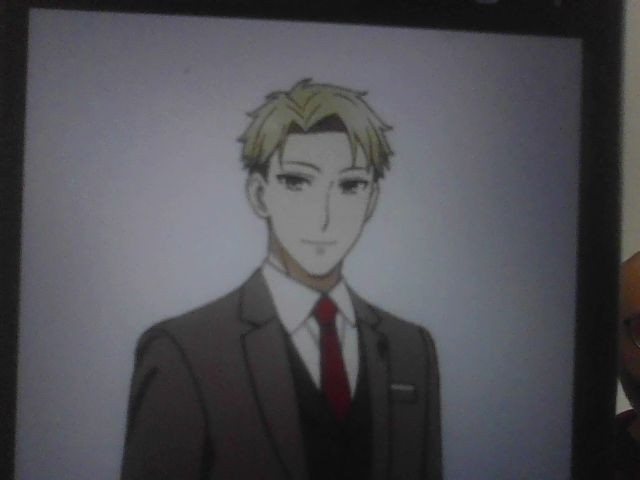

In [ ]:
IMG_SIZE = 224

img = cv2.imread("photo.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = preprocess_input(img)
img = np.expand_dims(img, axis=0)

cv2_imshow(cv2.imread("photo.jpg"))

In [ ]:
prediction = model.predict(img)
class_names = list(train_generator.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print("Predicted Character:", predicted_class)
print("Confidence:", round(confidence * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Character: Loid
Confidence: 92.3 %


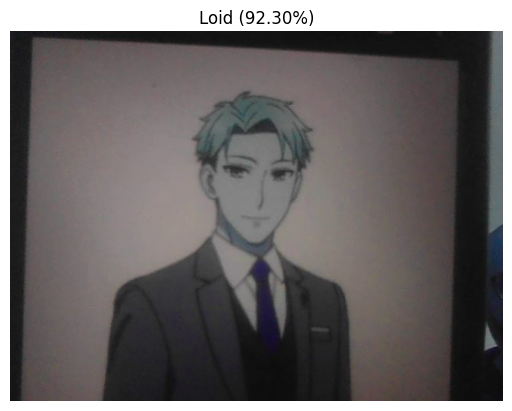

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(cv2.imread("photo.jpg"))
plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save("/content/drive/MyDrive/Operation Strix: Deep Learning for Spy x Family Character Recognition.keras")